## Setup
Install dependencies: `yt-dlp` (video download), `faster-whisper` (transcription), `rapidfuzz` (fuzzy text matching).

In [1]:
!pip install -q yt-dlp faster-whisper rapidfuzz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 83.5 MB/s eta 0:00:00


## Download source video
Set the source **URL** below to the video to search for the target phrase in.

In [2]:
import yt_dlp

def download_video(url, output_path="video.mp4"):
    ydl_opts = {
        "format": "bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best",
        "outtmpl": output_path,
        "merge_output_format": "mp4",
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])
    return output_path

# Source video URL — change this to search a different video
url = " https://ok.ru/video/248244667877"
video_path = download_video(url)
print(f"Downloaded to {video_path}")

[generic] Extracting URL:  https://ok.ru/video/248244667877
[generic] 248244667877: Downloading webpage
[redirect] Following redirect to https://ok.ru/video/248244667877
[Odnoklassniki] Extracting URL: https://ok.ru/video/248244667877
[Odnoklassniki] 248244667877: Downloading desktop webpage
[Odnoklassniki] 248244667877: Downloading m3u8 information
[info] 248244667877: Downloading 1 format(s): hls-2565
[hlsnative] Downloading m3u8 manifest
[hlsnative] Total fragments: 327
[download] Destination: video.mp4
[download] 100% of  997.69MiB in 00:01:14 at 13.35MiB/s                  
[FixupM3u8] Fixing MPEG-TS in MP4 container of "video.mp4"
Downloaded to video.mp4


## Transcribe audio
Run Whisper (GPU) to get word-level timestamps for the whole video.

In [3]:
from faster_whisper import WhisperModel

model = WhisperModel("medium", device="cuda", compute_type="float16")

def transcribe(video_path):
    segments, info = model.transcribe(video_path, word_timestamps=True)
    words = []
    for segment in segments:
        for word in segment.words:
            words.append({
                "word": word.word.strip(),
                "start": word.start,
                "end": word.end,
            })
    return words

words = transcribe(video_path)
print(f"Transcribed {len(words)} words")
print(" ".join(w["word"] for w in words[:50]))

Transcribed 4242 words
Thank you very much. I'm sorry, I'm sorry, I'm sorry, I'm sorry, I'm sorry. I've got you. Now look here. But ma 'am. Close the window, John. To Sherlock Holmes, she was always the woman, the beautiful Irina Adler, of dubious and questionable memory. At the time of our involvement


## Locate target phrase
Fuzzy-match a sliding window of transcript words against the **target phrase** to find its timestamp in the video.

In [4]:
from rapidfuzz import fuzz

def find_phrase(words, target_phrase, window_slack=3, score_threshold=75):
    """
    Slides a window over the transcript words, roughly sized to the target
    phrase length (+/- slack to absorb Whisper insertions/omissions),
    and scores each window against the target phrase.
    """
    target_words = target_phrase.split()
    target_len = len(target_words)
    target_norm = target_phrase.lower().strip()

    best_match = None
    best_score = 0

    for window_len in range(max(1, target_len - window_slack), target_len + window_slack + 1):
        for i in range(len(words) - window_len + 1):
            window = words[i:i + window_len]
            window_text = " ".join(w["word"] for w in window).lower().strip()

            score = fuzz.ratio(window_text, target_norm)

            if score > best_score:
                best_score = score
                best_match = {
                    "text": window_text,
                    "start": window[0]["start"],
                    "end": window[-1]["end"],
                    "score": score,
                    "word_range": (i, i + window_len),
                }

    if best_match and best_match["score"] >= score_threshold:
        return best_match
    return None

# The phrase we are searching for in the transcript
target_phrase = "My mind rebels at stagnation"
match = find_phrase(words, target_phrase)

if match:
    print(f"Match found: '{match['text']}' (score: {match['score']:.1f})")
    print(f"Timestamp: {match['start']:.2f}s - {match['end']:.2f}s")
else:
    print("No confident match found — try lowering score_threshold")

Match found: 'my mind rebels at stagnation.' (score: 98.2)
Timestamp: 324.62s - 327.60s


## Extract a preview frame
Grab the video frame at the start of the matched phrase.

In [5]:
import subprocess

def extract_frame(video_path, timestamp, output_image="frame.jpg"):
    subprocess.run([
        "ffmpeg", "-y",
        "-ss", str(timestamp),
        "-i", video_path,
        "-frames:v", "1",
        "-q:v", "2",  # high quality jpeg
        output_image
    ], check=True, capture_output=True)
    return output_image

if match:
    frame_path = extract_frame(video_path, match["start"])
    print(f"Frame saved to {frame_path}")

Frame saved to frame.jpg


## Active Speaker Detection (ASD) setup
Clone the LR-ASD repo and install its dependencies (with a pinned `scenedetect` version for compatibility).

In [6]:
!git clone -q https://github.com/Junhua-Liao/LR-ASD.git
!pip install -q python_speech_features "scenedetect[opencv]"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.2/146.2 kB 6.4 MB/s eta 0:00:00


In [7]:
!pip uninstall -y scenedetect -q
!pip install -q "scenedetect==0.5.6.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 5.3 MB/s eta 0:00:00


### Compatibility patch
Fix deprecated `np.int` usage in the LR-ASD face detector for newer numpy versions.

In [8]:
!sed -i 's/np\.int)/int)/g; s/np\.int(/int(/g' LR-ASD/model/faceDetector/s3fd/box_utils.py
!grep -n "int" LR-ASD/model/faceDetector/s3fd/box_utils.py | grep -i "np\.int\b"

## Prepare ASD input clip
Copy the video into LR-ASD's demo folder and compute the time window (around the matched phrase) to run ASD on.

In [9]:
import os, shutil

ASD_DIR = "LR-ASD"
DEMO_NAME = "quest1_clip"
DEMO_FOLDER = os.path.join(ASD_DIR, "demo")
os.makedirs(DEMO_FOLDER, exist_ok=True)

shutil.copy(video_path, os.path.join(DEMO_FOLDER, f"{DEMO_NAME}.mp4"))

PAD = 0
ASD_START = max(0, int(match["start"] - PAD))
ASD_DURATION = int((match["end"] - match["start"]) + 2 * PAD) + 1

print(f"ASD window: {ASD_START}s -> {ASD_START + ASD_DURATION}s")

ASD window: 324s -> 327s


## Run Active Speaker Detection
Runs LR-ASD's `Columbia_test.py` over the computed window.

In [10]:
%cd LR-ASD
!python Columbia_test.py \
  --videoName {DEMO_NAME} \
  --videoFolder demo \
  --start {ASD_START} \
  --duration {ASD_DURATION}
%cd ..

/content/LR-ASD
/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1KafnHz7ccT-3IyddBsL5yi2xGtxAKypt
To: /content/LR-ASD/model/faceDetector/s3fd/sfd_face.pth
100% 89.8M/89.8M [00:01<00:00, 75.8MB/s]
2026-08-26 15:33:49 Extract the video and save in demo/quest1_clip/pyavi/video.avi 
2026-08-26 15:33:49 Extract the audio and save in demo/quest1_clip/pyavi/audio.wav 
2026-08-26 15:33:50 Extract the frames and save in demo/quest1_clip/pyframes 
 95% 72/76 [00:00<00:00, 295.59frames/s]
demo/quest1_clip/pyavi/video.avi - scenes detected 1
2026-08-26 15:33:50 Scene detection and save in demo/quest1_clip/pywork 
2026-08-26 15:33:54 Face detection and save in demo/quest1_clip/pywork 
2026-08-26 15:33:54 Face track and detected 1 tracks 
100% 1/1 [00:00<00:00,  1.78it/s]
2026-0

## Load ASD results
Load the face tracks and per-frame active-speaker scores produced by LR-ASD.

In [11]:
import pickle
import numpy as np

pywork_path = os.path.join(ASD_DIR, "demo", DEMO_NAME, "pywork")

with open(os.path.join(pywork_path, "tracks.pckl"), "rb") as f:
    tracks = pickle.load(f)

with open(os.path.join(pywork_path, "scores.pckl"), "rb") as f:
    scores = pickle.load(f)

FPS = 25  # Columbia_test.py always re-encodes to 25fps internally

print(f"Loaded {len(tracks)} tracks, {len(scores)} score arrays")

Loaded 1 tracks, 1 score arrays


## Check if phrase is spoken on-screen
Convert the phrase's timestamps to frame indices and check for a face with a high active-speaker score in that window.

In [12]:
# Calculate start and end frames for the whole phrase
FPS = 25.0
start_frame = int(round((match["start"] - ASD_START) * FPS))
end_frame = int(round((match["end"] - ASD_START) * FPS))

def get_max_speaker_score(tracks, scores, start_idx, end_idx):
    """Finds the highest active speaker score within a frame window."""
    best = {"score": -float('inf'), "track_id": None}

    for track_id, (track, score) in enumerate(zip(tracks, scores)):
        frame_nums = track["track"]["frame"]

        # Find all frames in this track that fall within our phrase window
        valid_indices = np.where((frame_nums >= start_idx) & (frame_nums <= end_idx))[0]

        if len(valid_indices) == 0:
            continue

        # Get the maximum score for this face during the phrase
        phrase_scores = [score[i] for i in valid_indices if i < len(score)]
        max_s = float(np.max(phrase_scores))

        if max_s > best["score"]:
            best = {"score": max_s, "track_id": track_id}

    return best if best["track_id"] is not None else None

result = get_max_speaker_score(tracks, scores, start_frame, end_frame)

if result and result["score"] >= 0:
    print(f"Active speaker found! (Peak score={result['score']:.2f}) -> ON-SCREEN dialogue confirmed")
else:
    best_score = result["score"] if result else None
    print(f"No active speaker found in window (Best score={best_score}) -> OFF-SCREEN / Narration")

Active speaker found! (Peak score=1.10) -> ON-SCREEN dialogue confirmed


## Show result
If the phrase was spoken on-screen, display the matching frame; otherwise report it as off-screen narration.

Timestamp : 00:05:24.620
Frame     : 7783
Text      : "My mind rebels at stagnation"


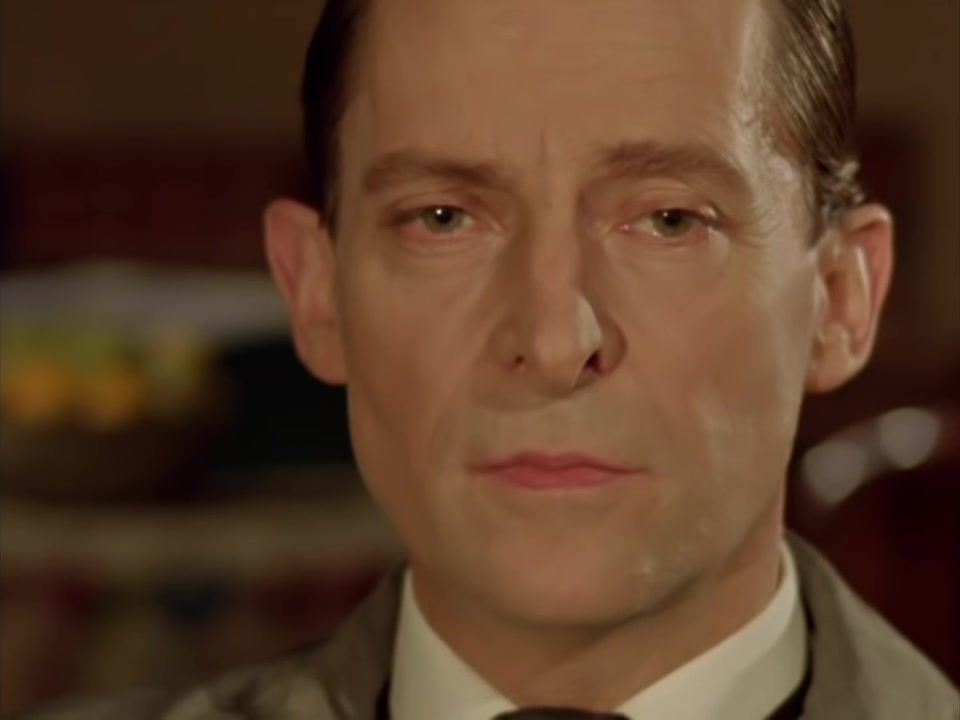

In [14]:
import subprocess
from IPython.display import Image, display

def get_video_fps(path):
    """Gets the native frame rate of the source video via ffprobe."""
    result = subprocess.run(
        ["ffprobe", "-v", "0", "-of", "csv=p=0",
         "-select_streams", "v:0", "-show_entries", "stream=r_frame_rate", path],
        capture_output=True, text=True, check=True
    )
    num, den = result.stdout.strip().split('/')
    return float(num) / float(den)

def format_timestamp(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = seconds % 60
    return f"{hours:02d}:{minutes:02d}:{secs:06.3f}"

def extract_frame(video_path, timestamp, output_image="matched_frame.jpg"):
    subprocess.run([
        "ffmpeg", "-y",
        "-ss", str(timestamp),
        "-i", video_path,
        "-frames:v", "1",
        "-q:v", "2",
        output_image
    ], check=True, capture_output=True)
    return output_image

if match and result and result["score"] >= 0:
    video_fps = get_video_fps(video_path)
    frame_number = int(round(match["start"] * video_fps))
    timestamp_str = format_timestamp(match["start"])

    frame_path = extract_frame(video_path, match["start"])

    print(f"Timestamp : {timestamp_str}")
    print(f"Frame     : {frame_number}")
    print(f"Text      : \"{target_phrase}\"")
    display(Image(filename=frame_path))
else:
    print("Dialogue is OFF-SCREEN / narration — no on-screen frame to display.")